# --- MODELIZACIÓN TFG: **Teacher-Student (Destilación de Conocimiento)** ---

En este Notebook Jupyter se lleva a cabo la sección de Modelización del Proyecto en: **"Modelos Predictivos para la Detección de Inestabilidades de los Modos Alfvénicos del Plasma en el Dispositivo Tokamak DIII-D"**.

A partir de la base de datos generada (*./BaseDeDatos/data_final.csv*), se diseña la arquitectura de *Maestro-Estudiante* ("Destilamiento de Conocimiento") con modelos de Machine Learning con el fin de entrenar un modelo subrogado que a partir de las variables de entrada de la base de datos sea capaz de determinar si existe inestabilidad o no en el dispositivo nuclear, y en caso afirmativo determinar su tipología alfvénica. Además, se añade una sección de evaluación de los modelos y de interpretabilidad con la técnica post-hoc de *SHAP* para métodos basados en árboles de decisión.

## *Fase 1:* **PREPARACIÓN Y SPLIT DE DATOS**

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import shap
import glob
import matplotlib.pyplot as plt

from scipy.special import softmax

In [2]:
# ==========================================
# FASE 1: PREPARACIÓN Y SPLIT DE DATOS
# ==========================================
def load_and_prepare_data(filepath):
    print("1. Cargando y preparando los datos...")
    archivos_csv = glob.glob(f"{filepath}*.csv")
    lista_dataframes = [pd.read_csv(archivo) for archivo in archivos_csv]
    df = pd.concat(lista_dataframes, ignore_index=True)

    # Sustituir Estable/Ruido por Estable
    df['tipo_inestabilidad'] = df['tipo_inestabilidad'].replace('Estable/Ruido', 'Estable')

    # Definir los grupos de variables
    base_features = ['bet0_f', 'Adens', 'Bdens', 'Beam Ion Effective Temp(keV)', 'n']
    extra_features = ['gam', 'om_r', 'gam_var', 'om_r_var', 'pos_radial', 'diff_m']
    target = 'tipo_inestabilidad'

    # Codificar la variable objetivo (de string a enteros 0-5)
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df[target])

    # Matrices de características
    X_base = df[base_features]
    X_all = df[base_features + extra_features]


    # Matriz con Variable Objetivo
    y = df['target_encoded']

    # Split de validación
    # Usamos stratify=y para asegurar balance de inestabilidades en train y test
    X_train_all, X_test_all, X_train_base, X_test_base, y_train, y_test = train_test_split(
        X_all, X_base, y, test_size=0.2, random_state=42, stratify=y
    )

    return X_train_all, X_test_all, X_train_base, X_test_base, y_train, y_test, le

## *Fase 2:* ENTRENAMIENTO DEL MODELO **MAESTRO**

In [3]:
# ==========================================
# FASE 2: ENTRENAMIENTO DEL MODELO MAESTRO
# ==========================================
def train_teacher_model(X_train_all, y_train, num_classes):
    print("2. Entrenando el modelo Maestro (Acceso a física completa)...")
    # Usamos un clasificador XGBoost de 250 estimadores
    teacher = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        n_estimators=250,
        max_depth=5,
        learning_rate=0.15,
        random_state=42,
        n_jobs=-1
    )

    teacher.fit(X_train_all, y_train)
    return teacher

## *Fase 3*: DESTILACIÓN Y ENTRENAMIENTO DEL **ALUMNO**

In [4]:
# ==========================================
# FASE 3: DESTILACIÓN Y ENTRENAMIENTO DEL ALUMNO
# ==========================================
def train_student_model(teacher, X_train_all, X_train_base, num_classes, y_train):
    print("3. Generando Soft Labels y entrenando al Alumno...")

    # Predecir los targets con Teacher
    soft_targets_train = teacher.predict_proba(X_train_all)

    # El Alumno solo ve X_train_base, ya que el resto de las variables usadas por el Maestro forman parte de la salida de FAR3d,
    # y por tanto no pueden ser usadas por el modelo sustitutivo para realizar su predicción
    # El modelo alumno es de tipo regressor para imitar así las probabilidades ("soft labels") del modelo maestro
    student_base_estimator = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    # MultiOutputRegressor entrena un RandomForestRegressor independiente para predecir la probabilidad de cada clase
    student = MultiOutputRegressor(student_base_estimator)
    student.fit(X_train_base, soft_targets_train)

    return student

## *Fase 4:* EVALUACIÓN (INFERENCIA REAL)

In [5]:
# ==========================================
# FASE 4: EVALUACIÓN Y MATRICES DE CONFUSIÓN
# ==========================================
def evaluate_models(teacher, student, X_test_all, X_test_base, y_test, target_names):
    print("4. Evaluando modelos en el conjunto de Test y generando Matrices de Confusión...")

    # --- Predicciones ---
    # Predicción del Maestro
    y_pred_teacher = teacher.predict(X_test_all)
    acc_teacher = accuracy_score(y_test, y_pred_teacher)

    # Predicción del Alumno
    student_predicted_probs = student.predict(X_test_base)
    y_pred_student = np.argmax(student_predicted_probs, axis=1)
    acc_student = accuracy_score(y_test, y_pred_student)

    # --- Reporte en texto ---
    print(f"\n--- Resultados de Accuracy ---")
    print(f"Maestro (12 variables): {acc_teacher:.4f}")
    print(f"Alumno (5 variables):  {acc_student:.4f}")

    print("\n--- Reporte del Modelo Sustitutivo (Alumno) ---")
    print(classification_report(y_test, y_pred_student, target_names=target_names))

    print("\n--- Reporte del Modelo Maestro ---")
    print(classification_report(y_test, y_pred_teacher, target_names=target_names))

    # --- Matrices de Confusión ---
    # Calcular las matrices
    cm_teacher = confusion_matrix(y_test, y_pred_teacher)
    cm_student = confusion_matrix(y_test, y_pred_student)

    # Configurar el gráfico lado a lado (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Dibujar Matriz del Maestro
    disp_teacher = ConfusionMatrixDisplay(confusion_matrix=cm_teacher, display_labels=target_names)
    disp_teacher.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Matriz de Confusión: MAESTRO\n(5 Entradas + 7 Variables Físicas)')
    axes[0].set_xlabel('Predicción').set_fontsize(12)
    axes[0].set_ylabel('Valor Real').set_fontsize(12)
    disp_teacher.ax_.tick_params(axis='x', labelsize=14)
    disp_teacher.ax_.tick_params(axis='y', labelsize=14)


    # Dibujar Matriz del Alumno
    disp_student = ConfusionMatrixDisplay(confusion_matrix=cm_student, display_labels=target_names)
    disp_student.plot(ax=axes[1], cmap='Greens', colorbar=False)
    axes[1].set_title('Matriz de Confusión: ALUMNO\n(5 Entradas Iniciales)')
    axes[1].set_xlabel('Predicción').set_fontsize(12)
    axes[1].set_ylabel('Valor Real').set_fontsize(12)
    disp_student.ax_.tick_params(axis='x', labelsize=14)
    disp_student.ax_.tick_params(axis='y', labelsize=14)

    # Ajustar layout para que no se solapen y mostrar
    plt.tight_layout()
    plt.show()

## *Fase 5:* EXPLICABILIDAD FÍSICA CON **SHAP**

In [20]:
# ==========================================
# FASE 5: EXPLICABILIDAD FÍSICA CON SHAP
# ==========================================
def analyze_physics_with_shap(student, X_test_base, class_index, class_name):
    print(f"Iniciando análisis SHAP para la clase: {class_name}...")

    # Extraemos el modelo regresor específico que predice la inestabilidad
    class_estimator = student.estimators_[class_index]

    # Tomar una muestra representativa (300 datos)
    # Si X_test_base es un DataFrame de Pandas:
    if isinstance(X_test_base, pd.DataFrame):
        X_test_sample = X_test_base.sample(n=300, random_state=42)
    else: # Si es un array de Numpy
        np.random.seed(42)
        indices = np.random.choice(X_test_base.shape[0], size=300, replace=False)
        X_test_sample = X_test_base[indices]

    explainer = shap.TreeExplainer(class_estimator)
    shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

    # Gráfico: Importancia global y dirección del efecto
    plt.figure(figsize=(10, 6))
    plt.title(f"Impacto de variables en la Inestabilidad: {class_name} (SHAP Summary)")
    shap.summary_plot(shap_values, X_test_sample, show=False)
    plt.tight_layout()
    plt.show()

## *Fase 6:* Visualización de Mapas de Densidad

In [17]:
def visualizar_mapa_de_densidad(X_train_base, X_test_base, y_train, y_test):
  # 1. Juntar dataframes
  X = pd.concat([X_train_base, X_test_base], axis=0, ignore_index=True)
  y = pd.concat([y_train, y_test], axis=0, ignore_index=True)
  df = pd.concat([X, y], axis=1)
  df["target_encoded"] = np.where(df["target_encoded"] == 2, 0, 1)
  df_estable = df[df["target_encoded"] == 0]
  print(df.head())

  # 2. Definimos las variables predictoras
  predictores = ["bet0_f", "Adens", "Bdens", "Beam Ion Effective Temp(keV)"]

  # 3. Configuramos la cuadrícula de Seaborn
  g = sns.PairGrid(df_estable, vars=predictores, diag_sharey=False)

  # 4. En la diagonal mostramos la distribución unidimensional (histograma + densidad)
  # g.map_diag(sns.kdeplot, fill=True, color="orange", alpha=0.5)
  g.map_lower(sns.kdeplot, fill=True, color="blue", alpha=0.5, thresh=0.1, levels=5)

  # Añadimos la leyenda y ajustamos el título
  g.fig.suptitle("Mapas de Densidad de los Casos ESTABLES", y=1.02, fontsize=16)

  plt.show()

## *Función Auxiliar*: SMOTE + Destilación con Teacher

In [8]:
from imblearn.over_sampling import SMOTE
import numpy as np

def augment_with_smote_and_teacher(X_train_all, y_train, teacher, num_classes):
    print("Aplicando SMOTE para balancear las 7 clases (en el espacio de 12 dimensiones)...")

    # SMOTE generará nuevos datos hasta que todas las clases tengan
    # la misma cantidad de filas que la clase mayoritaria.
    smote = SMOTE(random_state=42)
    X_train_all_aug, y_train_aug = smote.fit_resample(X_train_all, y_train)

    print(f"Datos originales: {X_train_all.shape[0]} filas. Datos tras SMOTE: {X_train_all_aug.shape[0]} filas.")

    # Finalmente, extraer las 5 primeras columnas del Dataframe (variables de entrada para el modelo Alumno)
    if isinstance(X_train_all_aug, pd.DataFrame):
        X_train_base_aug = X_train_all_aug.iloc[:, :5]
    else:
        X_train_base_aug = X_train_all_aug[:, :5]

    return X_train_base_aug, X_train_all_aug, y_train_aug

## **PROGRAMA PRINCIPAL (MAIN)**

1. Cargando y preparando los datos...
2. Entrenando el modelo Maestro (Acceso a física completa)...
Aplicando SMOTE para balancear las 7 clases (en el espacio de 12 dimensiones)...
Datos originales: 11073 filas. Datos tras SMOTE: 20083 filas.
3. Generando Soft Labels y entrenando al Alumno...
4. Evaluando modelos en el conjunto de Test y generando Matrices de Confusión...

--- Resultados de Accuracy ---
Maestro (12 variables): 0.9906
Alumno (5 variables):  0.8693

--- Reporte del Modelo Sustitutivo (Alumno) ---
              precision    recall  f1-score   support

         BAE       0.90      0.89      0.89       717
         EAE       0.81      0.83      0.82       386
     Estable       0.90      0.86      0.88       619
         GAE       0.47      0.47      0.47        17
         NAE       0.86      0.87      0.86       288
        RSAE       0.88      0.93      0.90       122
         TAE       0.86      0.88      0.87       620

    accuracy                           0.87      

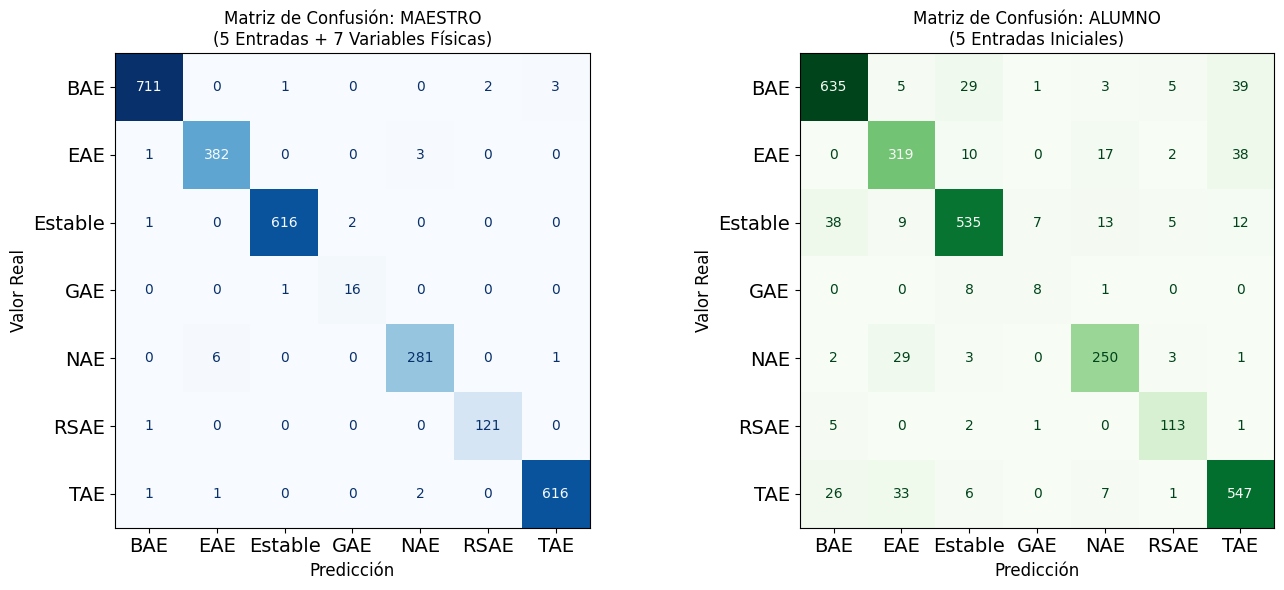

In [10]:
CSV_PATH = 'data_final'

try:
    # 1. Carga y Split
    X_train_all, X_test_all, X_train_base, X_test_base, y_train, y_test, label_encoder = load_and_prepare_data(CSV_PATH)
    num_classes = len(label_encoder.classes_)
    class_names = label_encoder.classes_

    # 2. Entrenamiento
    teacher_model = train_teacher_model(X_train_all, y_train, num_classes)

    # 3. Aumentar datos con SMOTE y crear Soft targets asignados por teacher
    X_train_base_aug, X_train_all_aug, y_train_aug = augment_with_smote_and_teacher(
        X_train_all, y_train, teacher_model, num_classes
    )
    student_model = train_student_model(teacher_model, X_train_all_aug, X_train_base_aug, num_classes, y_train_aug)

    # 4. Evaluación
    evaluate_models(teacher_model, student_model, X_test_all, X_test_base, y_test, class_names)

except FileNotFoundError:
    print(f"Error: No se ha encontrado el archivo {CSV_PATH}.")

   bet0_f  Adens  Bdens  Beam Ion Effective Temp(keV)  n  target_encoded
0  0.0400    0.5    0.4                            40  2               6
1  0.0088    2.0    0.6                            20  2               2
2  0.0322    8.0    0.1                           100  4               4
3  0.0361    4.0    0.1                            40  2               0
4  0.0283    4.0    0.3                            80  2               6
   bet0_f  Adens  Bdens  Beam Ion Effective Temp(keV)  n  target_encoded
0  0.0400    0.5    0.4                            40  2               1
1  0.0088    2.0    0.6                            20  2               0
2  0.0322    8.0    0.1                           100  4               1
3  0.0361    4.0    0.1                            40  2               1
4  0.0283    4.0    0.3                            80  2               1


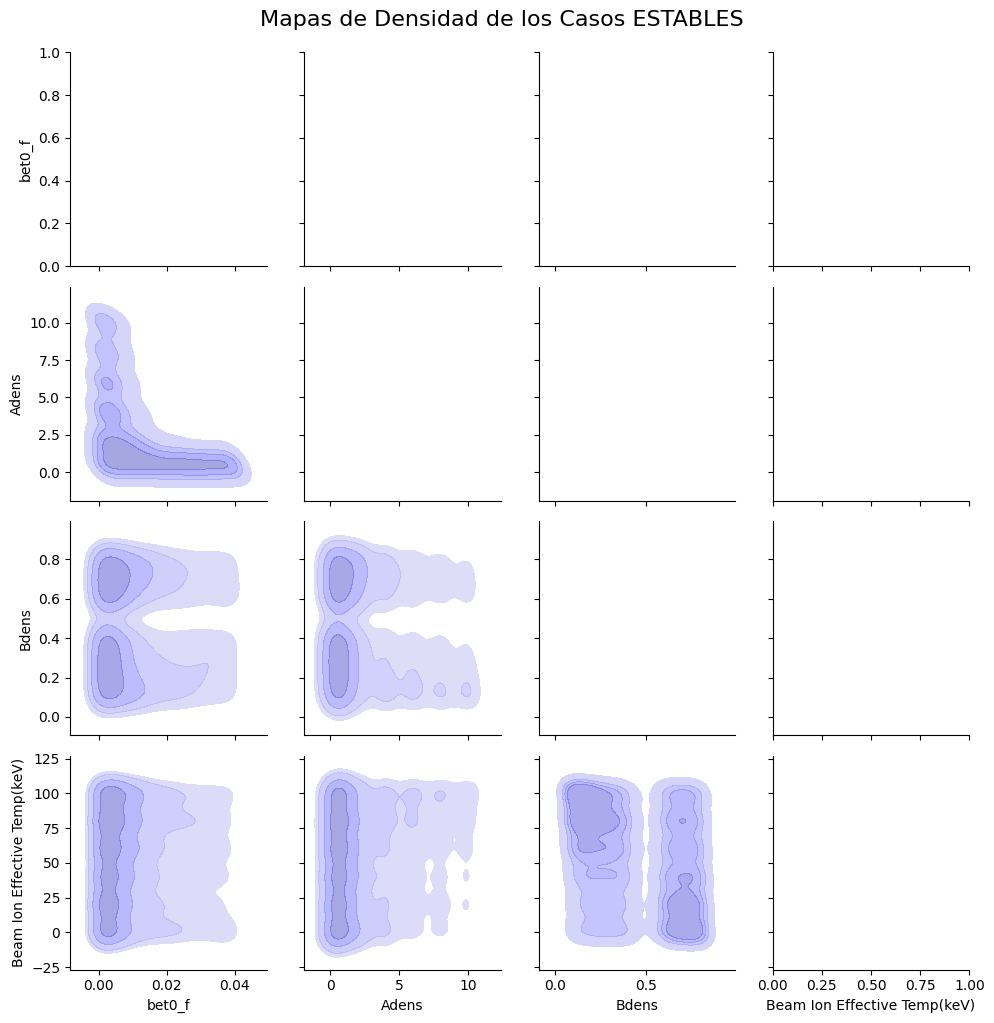

In [18]:
# 5. Visualizar mapas de densidad
visualizar_mapa_de_densidad(X_train_base_aug, X_test_base, y_train_aug, y_test)

Iniciando análisis SHAP para la clase: BAE...


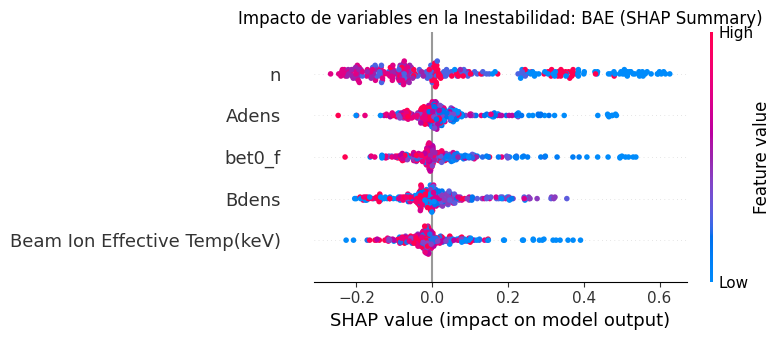

Iniciando análisis SHAP para la clase: EAE...


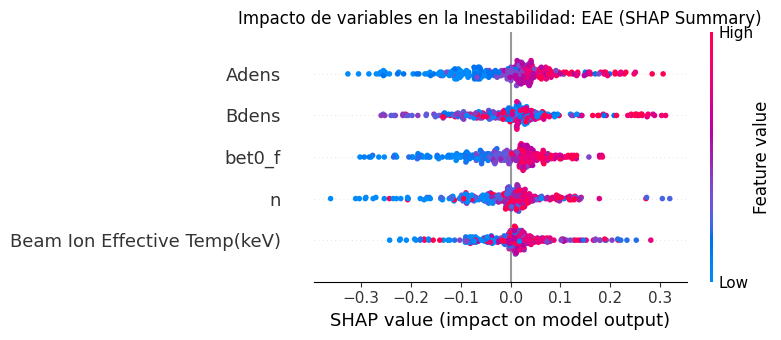

Iniciando análisis SHAP para la clase: Estable...


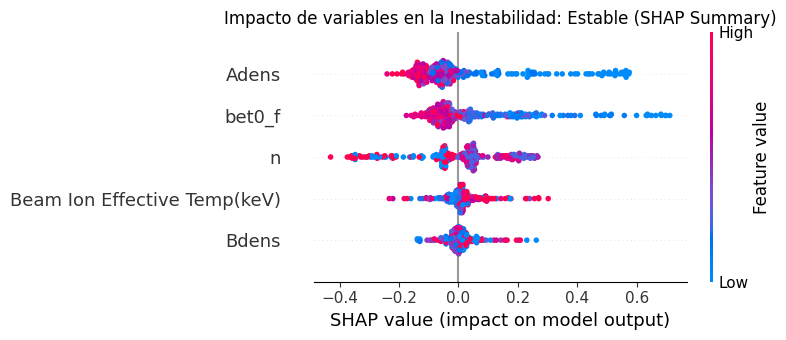

Iniciando análisis SHAP para la clase: GAE...


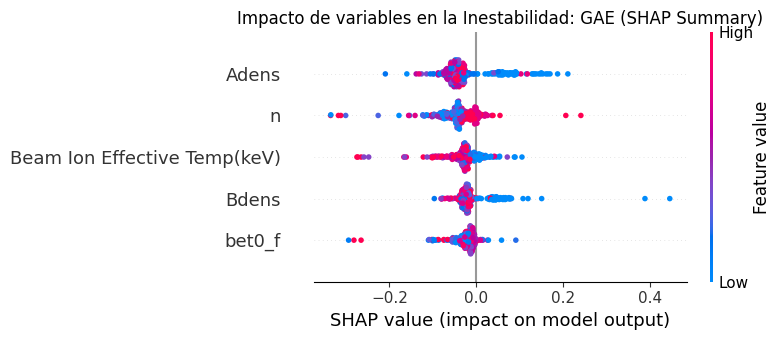

Iniciando análisis SHAP para la clase: NAE...


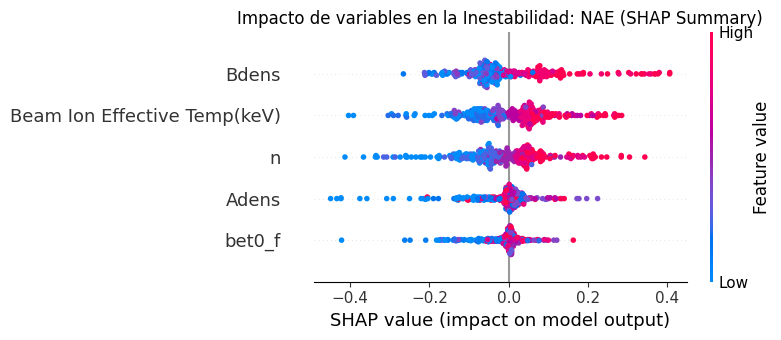

Iniciando análisis SHAP para la clase: RSAE...


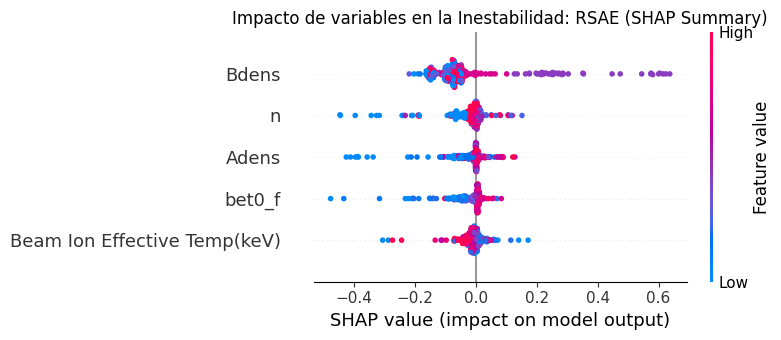

Iniciando análisis SHAP para la clase: TAE...


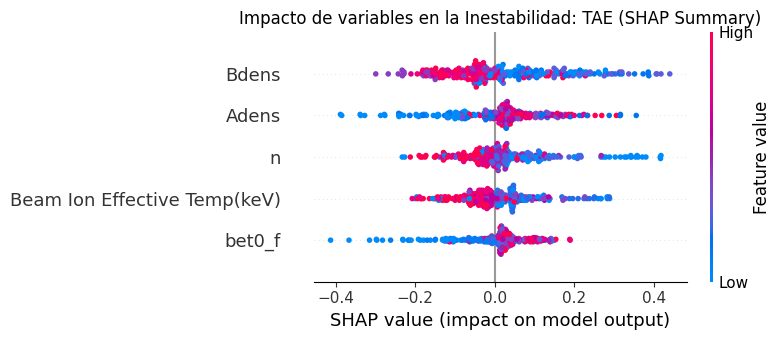

In [21]:
# 6. XAI (Explicabilidad)
for target_class_to_analyze in class_names:
    class_idx = np.where(class_names == target_class_to_analyze)[0][0]
    analyze_physics_with_shap(student_model, X_test_base, class_index=class_idx, class_name=target_class_to_analyze)